  STRATEGIA GENERAL 3-IMPULSE
Raggio di Apogeo (Rb): 12712.33 km
Alpha 1 (Perigeo):     4.8666 deg
Alpha 2 (Apogeo):      38.6893 deg
Delta V Totale:        5.5531 km/s
  - Burn 1 (V, N):     [0.9682, 0.7210] km/s
  - Burn 2 (V, N):     [-1.0397, -2.9616] km/s
  - Burn 3 (V, N):     [-1.0259, -0.6362] km/s


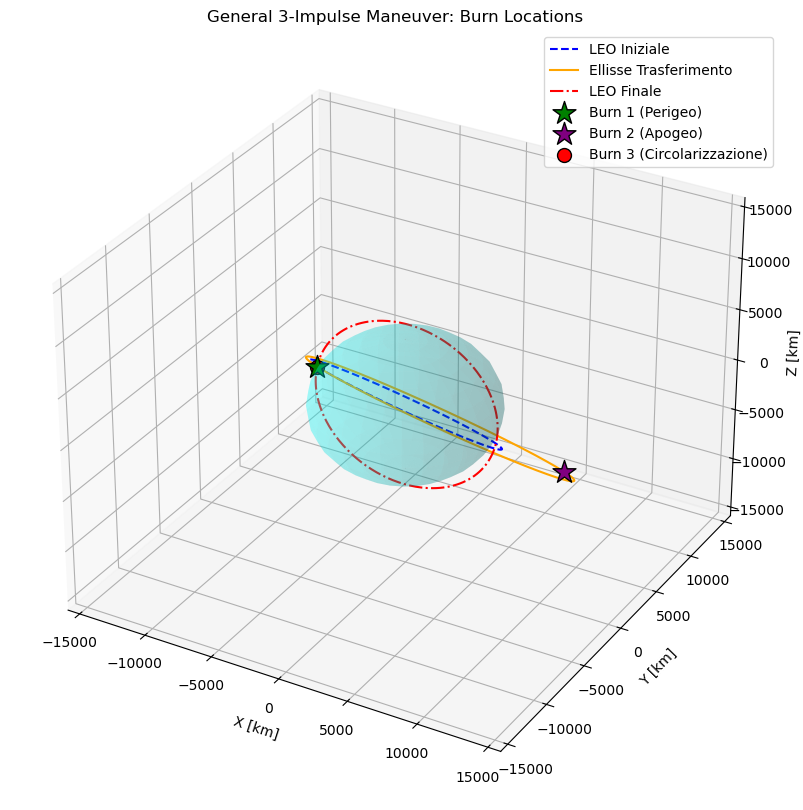

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import AbsoluteDate, TimeScalesFactory
from org.orekit.utils import Constants

# ==========================================
# 1. INIZIALIZZAZIONE AMBIENTE OREKIT
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

mu = Constants.WGS84_EARTH_MU
R_Earth = Constants.WGS84_EARTH_EQUATORIAL_RADIUS
J2 = Constants.WGS84_EARTH_C20 * -1.0
h = 709000.0
R1 = R_Earth + h
Vc = np.sqrt(mu / R1)

# Geometria
inc1 = np.radians(50.0); inc2 = np.radians(98.2)
RAAN1 = np.radians(170.0); RAAN2 = np.radians(175.012)
DeltaOmega = RAAN2 - RAAN1
theta = np.arccos(np.cos(inc1)*np.cos(inc2) + np.sin(inc1)*np.sin(inc2)*np.cos(DeltaOmega))

# ==========================================
# 2. GRID SEARCH (General 3-Impulse)
# ==========================================
N_Rb = 200
N_alpha1 = 200
Rb_vec = np.linspace(1.01 * R1, 40 * R1, N_Rb)
alpha1_vec = np.linspace(0, theta / 2, N_alpha1)
DV_grid = np.full((N_alpha1, N_Rb), np.inf)

for i, Rb in enumerate(Rb_vec):
    atr = (R1 + Rb) / 2
    Vp = np.sqrt(mu * (2/R1 - 1/atr))
    Va = np.sqrt(mu * (2/Rb - 1/atr))
    for j, a1 in enumerate(alpha1_vec):
        a2 = theta - 2 * a1
        if a2 >= 0:
            dv1 = np.sqrt(Vc**2 + Vp**2 - 2*Vc*Vp*np.cos(a1))
            dv2 = 2 * Va * np.sin(a2 / 2)
            DV_grid[j, i] = 2 * dv1 + dv2

idx = np.unravel_index(np.argmin(DV_grid), DV_grid.shape)
Rb_opt = Rb_vec[idx[1]]
a1_opt = alpha1_vec[idx[0]]
a2_opt = theta - 2 * a1_opt

print("========================================================")
print("  STRATEGIA GENERAL 3-IMPULSE")
print("========================================================")
print(f"Raggio di Apogeo (Rb): {Rb_opt/1000:.2f} km")
print(f"Alpha 1 (Perigeo):     {np.degrees(a1_opt):.4f} deg")
print(f"Alpha 2 (Apogeo):      {np.degrees(a2_opt):.4f} deg")
print(f"Delta V Totale:        {np.min(DV_grid)/1000:.4f} km/s")

# Parametri per componenti VNB
atr_opt = (R1 + Rb_opt) / 2
Vp_opt = np.sqrt(mu * (2/R1 - 1/atr_opt))
Va_opt = np.sqrt(mu * (2/Rb_opt - 1/atr_opt))

DV1_V = Vp_opt * np.cos(a1_opt) - Vc
DV1_N = Vp_opt * np.sin(a1_opt)
DV2_V = Va_opt * (np.cos(a2_opt) - 1)
DV2_N = -Va_opt * np.sin(a2_opt)
DV3_V = Vc * np.cos(a1_opt) - Vp_opt
DV3_N = -Vc * np.sin(a1_opt)

print(f"  - Burn 1 (V, N):     [{DV1_V/1000:.4f}, {DV1_N/1000:.4f}] km/s")
print(f"  - Burn 2 (V, N):     [{DV2_V/1000:.4f}, {DV2_N/1000:.4f}] km/s")
print(f"  - Burn 3 (V, N):     [{DV3_V/1000:.4f}, {DV3_N/1000:.4f}] km/s")

# ==========================================
# 3. GRAFICA 3D CON PUNTI DI MANOVRA (GENERAL)
# ==========================================
inertial_frame = FramesFactory.getEME2000()
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 6, 18, 12, 0, 0.0, utc) 

# Orbita 1: LEO Iniziale
u1 = np.arccos((-np.cos(inc2) + np.cos(theta)*np.cos(inc1)) / (np.sin(theta)*np.sin(inc1)))
orb1 = KeplerianOrbit(float(R1), 0.0, float(inc1), 0.0, float(RAAN1), float(u1), PositionAngleType.TRUE, inertial_frame, initial_date, float(mu))

# Orbita 2: Ellisse di Trasferimento (General)
e_trans = (Rb_opt - R1) / (Rb_opt + R1)
orb_trans = KeplerianOrbit(float(atr_opt), float(e_trans), float(inc1), 0.0, float(RAAN1), float(u1), PositionAngleType.TRUE, inertial_frame, initial_date, float(mu))

# Orbita 3: LEO Finale (Target)
orb2 = KeplerianOrbit(float(R1), 0.0, float(inc2), 0.0, float(RAAN2), 0.0, PositionAngleType.TRUE, inertial_frame, initial_date, float(mu))

def get_orbit_coords(orbit, num_points=300):
    T = orbit.getKeplerianPeriod()
    times = np.linspace(0, T, num_points)
    x, y, z = [orbit.shiftedBy(float(dt)).getPVCoordinates().getPosition().getX()/1000 for dt in times], \
              [orbit.shiftedBy(float(dt)).getPVCoordinates().getPosition().getY()/1000 for dt in times], \
              [orbit.shiftedBy(float(dt)).getPVCoordinates().getPosition().getZ()/1000 for dt in times]
    return x, y, z

# Estrazione coordinate 
x1, y1, z1 = get_orbit_coords(orb1)
xt, yt, zt = get_orbit_coords(orb_trans, 600) 
x2, y2, z2 = get_orbit_coords(orb2)

# --- CALCOLO COORDINATE DEI BURN (GENERAL) ---
pos_b1 = orb1.getPVCoordinates().getPosition()
xb1, yb1, zb1 = pos_b1.getX()/1000, pos_b1.getY()/1000, pos_b1.getZ()/1000

dt_apogee = float(orb_trans.getKeplerianPeriod() / 2.0)
pos_b2 = orb_trans.shiftedBy(dt_apogee).getPVCoordinates().getPosition()
xb2, yb2, zb2 = pos_b2.getX()/1000, pos_b2.getY()/1000, pos_b2.getZ()/1000

pos_b3 = orb_trans.shiftedBy(float(orb_trans.getKeplerianPeriod())).getPVCoordinates().getPosition()
xb3, yb3, zb3 = pos_b3.getX()/1000, pos_b3.getY()/1000, pos_b3.getZ()/1000

# --- SETUP PLOT 3D ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Terra
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
ax.plot_surface((R_Earth/1000)*np.cos(u)*np.sin(v), (R_Earth/1000)*np.sin(u)*np.sin(v), (R_Earth/1000)*np.cos(v), color='cyan', alpha=0.2)

# Traiettorie 
ax.plot(x1, y1, z1, label='LEO Iniziale', color='blue', linestyle='--')
ax.plot(xt, yt, zt, label='Ellisse Trasferimento', color='orange')
ax.plot(x2, y2, z2, label='LEO Finale', color='red', linestyle='-.')

# Marker
ax.scatter([xb1], [yb1], [zb1], color='green', s=300, marker='*', edgecolor='black', label='Burn 1 (Perigeo)', zorder=5)
ax.scatter([xb2], [yb2], [zb2], color='purple', s=300, marker='*', edgecolor='black', label='Burn 2 (Apogeo)', zorder=5)
ax.scatter([xb3], [yb3], [zb3], color='red', s=100, marker='o', edgecolor='black', label='Burn 3 (Circolarizzazione)', zorder=4)

# Vista
lim = Rb_opt / 800.0
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('General 3-Impulse Maneuver: Burn Locations')
ax.legend()

fig.savefig('general_3_impulse_plot.png', dpi=300, bbox_inches='tight')
plt.show()